# Linear Regression — Math Foundations

Linear regression is the simplest supervised learning algorithm — and the best place
to deeply understand the mathematics that underpins all of ML.

**What we derive:**
- The hypothesis function
- Mean Squared Error (MSE) cost function
- The Normal Equation (closed-form solution via calculus)
- Geometric interpretation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../..')
from src.utils import set_style

set_style()
np.set_printoptions(precision=4, suppress=True)

## 1. Hypothesis Function

Given a feature vector $\mathbf{x} \in \mathbb{R}^n$, the linear model predicts:

$$h_{\boldsymbol{\theta}}(\mathbf{x}) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n = \boldsymbol{\theta}^T \mathbf{x}$$

where we prepend $x_0 = 1$ (the bias term) so that $\boldsymbol{\theta}^T \mathbf{x}$ absorbs $\theta_0$.

For $m$ training samples stacked into a matrix $X \in \mathbb{R}^{m \times (n+1)}$:

$$\hat{\mathbf{y}} = X \boldsymbol{\theta}$$

In [2]:
# 4 training samples, 2 features
X_raw = np.array([[1.0, 2.0],
                  [2.0, 3.0],
                  [3.0, 1.0],
                  [4.0, 5.0]])

m, n = X_raw.shape

# Add bias column x0 = 1
X = np.hstack([np.ones((m, 1)), X_raw])   # shape (4, 3)
theta = np.array([0.5, 1.0, -0.5])        # [θ0, θ1, θ2]

y_hat = X @ theta
print('Design matrix X (with bias):')
print(X)
print('\nθ =', theta)
print('Predictions ŷ =', y_hat)

Design matrix X (with bias):
[[1. 1. 2.]
 [1. 2. 3.]
 [1. 3. 1.]
 [1. 4. 5.]]

θ = [ 0.5  1.  -0.5]
Predictions ŷ = [0.5 1.  3.  2. ]


## 2. Cost Function — Mean Squared Error (MSE)

We measure how wrong our predictions are with the **MSE cost function**:

$$J(\boldsymbol{\theta}) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_{\boldsymbol{\theta}}(\mathbf{x}^{(i)}) - y^{(i)} \right)^2$$

The $\frac{1}{2}$ is a convention that cancels the 2 that appears when we differentiate.  
In matrix form: $J(\boldsymbol{\theta}) = \frac{1}{2m} (X\boldsymbol{\theta} - \mathbf{y})^T (X\boldsymbol{\theta} - \mathbf{y})$

In [3]:
def compute_cost(X: np.ndarray, y: np.ndarray, theta: np.ndarray) -> float:
    """MSE cost: J(θ) = (1/2m) * ||Xθ - y||²"""
    m = len(y)
    residuals = X @ theta - y
    return float(residuals @ residuals) / (2 * m)


y_true = np.array([2.5, 4.0, 3.5, 7.0])

# Perfect θ (if we knew it) would give J≈0; random θ gives higher cost
theta_bad  = np.array([0.0, 0.0, 0.0])
theta_try  = np.array([0.5, 1.0, -0.5])

print(f'J(θ_zero) = {compute_cost(X, y_true, theta_bad):.4f}')
print(f'J(θ_try)  = {compute_cost(X, y_true, theta_try):.4f}')

J(θ_zero) = 10.4375
J(θ_try)  = 4.7812


## 3. Visualising the Cost Surface (1-D case)

For a single-feature model $h_\theta(x) = \theta_0 + \theta_1 x$ we can plot $J$ as a function of $\theta_1$ to see the bowl shape.

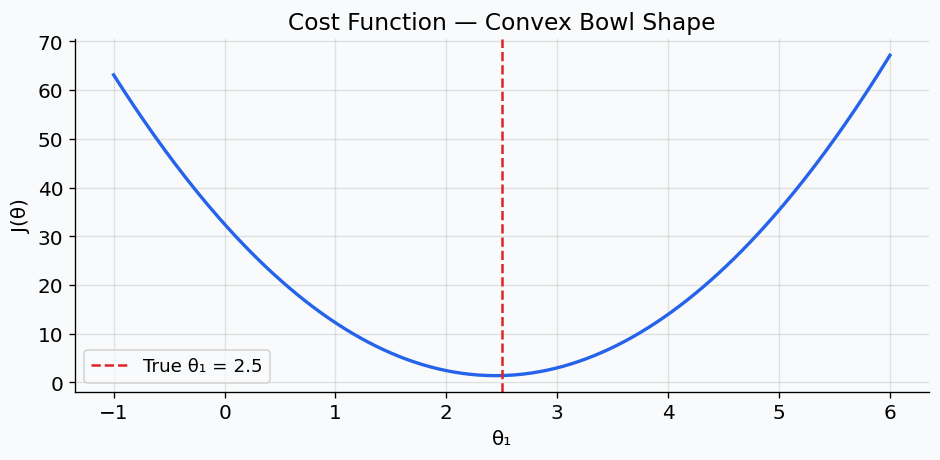

In [4]:
np.random.seed(0)
x = np.random.uniform(0, 5, 30)
y = 2.5 * x + np.random.randn(30) * 1.5   # true slope ≈ 2.5

X1 = np.column_stack([np.ones(len(x)), x])  # design matrix with bias

# Fix θ0 = 0 and sweep θ1
thetas = np.linspace(-1, 6, 300)
costs  = [compute_cost(X1, y, np.array([0, t])) for t in thetas]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thetas, costs, color='#2563EB', lw=2)
ax.axvline(2.5, color='#DC2626', linestyle='--', label='True θ₁ = 2.5')
ax.set_xlabel('θ₁')
ax.set_ylabel('J(θ)')
ax.set_title('Cost Function — Convex Bowl Shape')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Normal Equation — Closed-Form Solution

Setting $\nabla_\theta J = 0$ and solving gives the **Normal Equation**:

$$\boldsymbol{\theta}^* = (X^T X)^{-1} X^T \mathbf{y}$$

**Derivation (sketch):**

$$J(\boldsymbol{\theta}) = \frac{1}{2m} (X\boldsymbol{\theta} - y)^T(X\boldsymbol{\theta} - y)$$

$$\frac{\partial J}{\partial \boldsymbol{\theta}} = \frac{1}{m} X^T(X\boldsymbol{\theta} - y) = 0$$

$$X^T X \boldsymbol{\theta} = X^T y \quad \Rightarrow \quad \boldsymbol{\theta} = (X^TX)^{-1}X^Ty$$

> **Note:** This requires $X^TX$ to be invertible (no perfect multicollinearity).  
> Computationally $O(n^3)$ — slow for large feature counts; gradient descent preferred for big data.

Normal Equation θ: [0.0671 2.4258]
Cost at θ*: 1.3859


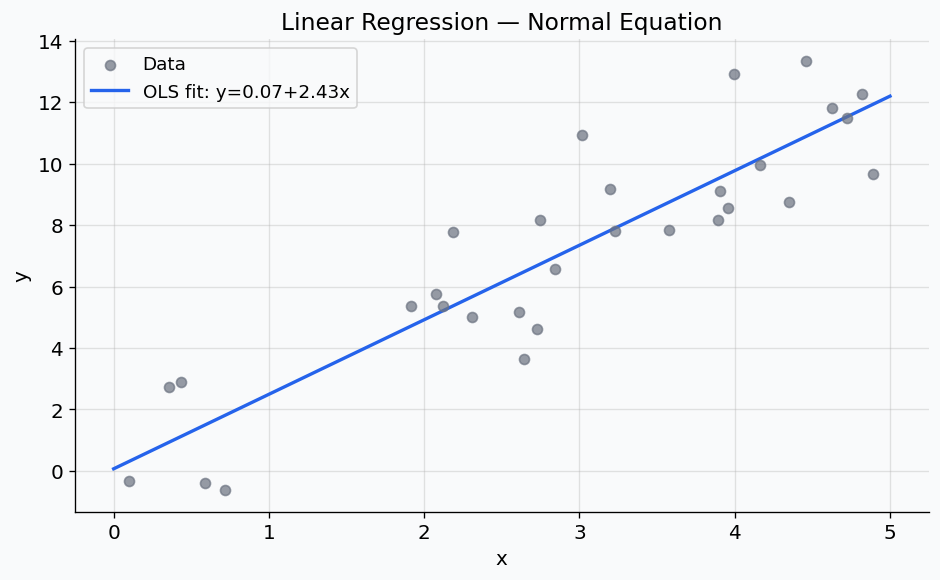

In [5]:
def normal_equation(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """θ* = (XᵀX)⁻¹ Xᵀy  — closed-form OLS solution."""
    return np.linalg.lstsq(X, y, rcond=None)[0]   # lstsq is more stable than inv


theta_ols = normal_equation(X1, y)
print(f'Normal Equation θ: {theta_ols}')   # [intercept, slope]
print(f'Cost at θ*: {compute_cost(X1, y, theta_ols):.4f}')

# Plot the fit
x_line = np.linspace(0, 5, 100)
y_line = theta_ols[0] + theta_ols[1] * x_line

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='#6B7280', alpha=0.7, label='Data', zorder=3)
ax.plot(x_line, y_line, color='#2563EB', lw=2, label=f'OLS fit: y={theta_ols[0]:.2f}+{theta_ols[1]:.2f}x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Regression — Normal Equation')
ax.legend()
plt.tight_layout()
plt.show()

## 5. R² — Coefficient of Determination

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

$R^2 = 1$ → perfect fit. $R^2 = 0$ → model no better than predicting the mean.

In [6]:
y_pred  = X1 @ theta_ols
ss_res  = np.sum((y - y_pred) ** 2)
ss_tot  = np.sum((y - y.mean()) ** 2)
r2      = 1 - ss_res / ss_tot

print(f'SS_res = {ss_res:.4f}')
print(f'SS_tot = {ss_tot:.4f}')
print(f'R²     = {r2:.4f}')

SS_res = 83.1554
SS_tot = 429.6085
R²     = 0.8064


## Summary

| Concept | Formula |
|---------|--------|
| Hypothesis | $\hat{y} = X\boldsymbol{\theta}$ |
| MSE cost | $J = \frac{1}{2m}\|X\theta-y\|^2$ |
| Normal equation | $\theta^* = (X^TX)^{-1}X^Ty$ |
| R² | $1 - SS_{res}/SS_{tot}$ |

**Next:** [From Scratch — implement gradient descent →](02_from_scratch_numpy.ipynb)